# 13 변수 중요도 분석 (XGBoost)

08·10장에서 핵심 예측 모델인 **XGBoost**를 type별로 학습하고, **어떤 피처가 판매량 예측에 기여하는지** 변수 중요도(feature importance)를 분석합니다.

## 왜 하는가

- 소매 수요예측에서 **lag·rolling·외생변수** 중 무엇이 type마다 다르게 작용하는지 파악
- 10장 XGBoost+임베딩 하이브리드 해석의 **피처 축** 이해
- 14장 Optuna 튜닝 전 **현재 고정 하이퍼파라미터** 모델의 변수 구조 파악

| 항목 | 내용 |
|------|------|
| 모델 | XGBoost (08장과 동일 하이퍼파라미터) |
| 단위 | **type 5개 각각** 독립 학습 |
| 데이터 | `df_weekly_features.parquet` 학습 구간 |
| 지표 | `feature_importances_` (gain 비율, % 정규화) |

**선행:** 02, 03 (피처 생성) | **다음:** 14 Optuna 튜닝

### ⓪ 환경 설정

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

NOTEBOOK_DIR = Path.cwd()
REPO_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'code' else NOTEBOOK_DIR
sys.path.insert(0, str(REPO_ROOT / 'code'))

from utils.paths import DATA_PROCESSED
from utils.splits import TRAIN_WEEK_MAX
from utils.device import device_label
from utils.feature_importance import (
    feature_cols, importance_by_type, importance_pivot,
)

print('Torch device:', device_label())
feat_df = pd.read_parquet(DATA_PROCESSED / 'df_weekly_features.parquet')
types = sorted(feat_df['type'].unique())
cols = feature_cols(feat_df)
print('types:', types)
print('피처 수:', len(cols), '| 학습 <=', TRAIN_WEEK_MAX)


Torch device: cpu
types: ['A', 'B', 'C', 'D', 'E']
피처 수: 17 | 학습 <= 201730


### ① type별 XGBoost 학습 · 변수 중요도

각 type 내 모든 family 시계열을 **패널**로 합쳐 XGBoost 1개를 학습합니다 (08장 `forecast_ml_panel`과 동일 구조).

In [2]:
imp_long = importance_by_type(feat_df, types)
imp_pivot = importance_pivot(imp_long)

print('=== type별 Top 10 피처 ===')
for t in types:
    top = imp_long[imp_long['type'] == t].nlargest(10, 'importance_pct')
    print(f'\n--- Type {t} ---')
    print(top.to_string(index=False))

display(imp_pivot.round(2))


=== type별 Top 10 피처 ===

--- Type A ---
type      feature  importance_pct
   A        lag_1       66.488899
   A  roll_mean_8       19.720501
   A  roll_mean_4        5.830800
   A roll_mean_12        4.627700
   A        lag_4        0.646600
   A        lag_8        0.440400
   A  onpromotion        0.391400
   A transactions        0.294900
   A        month        0.247900
   A        lag_2        0.223400

--- Type B ---
type      feature  importance_pct
   B        lag_1       59.112202
   B  roll_mean_4       20.098400
   B  roll_mean_8        9.444400
   B        lag_2        5.838800
   B roll_mean_12        2.488600
   B        lag_4        1.001200
   B transactions        0.427400
   B        lag_8        0.404500
   B    year_feat        0.176400
   B        month        0.145300

--- Type C ---
type      feature  importance_pct
   C        lag_1       69.646004
   C  roll_mean_4       18.603001
   C roll_mean_12        6.184700
   C        lag_4        1.719100
   C  roll

type,A,B,C,D,E
feature,,,,,
dcoilwtico,0.17,0.14,0.12,0.15,0.15
is_holiday,0.13,0.12,0.06,0.07,0.07
lag_1,66.49,59.11,69.65,74.43,69.96
lag_2,0.22,5.84,0.81,8.41,7.52
lag_4,0.65,1.00,1.72,0.36,0.39
lag_8,0.44,0.40,0.25,0.35,0.89
month,0.25,0.15,0.09,0.26,0.12
onpromotion,0.39,0.14,0.13,0.43,0.16
roll_mean_12,4.63,2.49,6.18,3.56,0.72


### ② 시각화 — type별 Top 15 피처

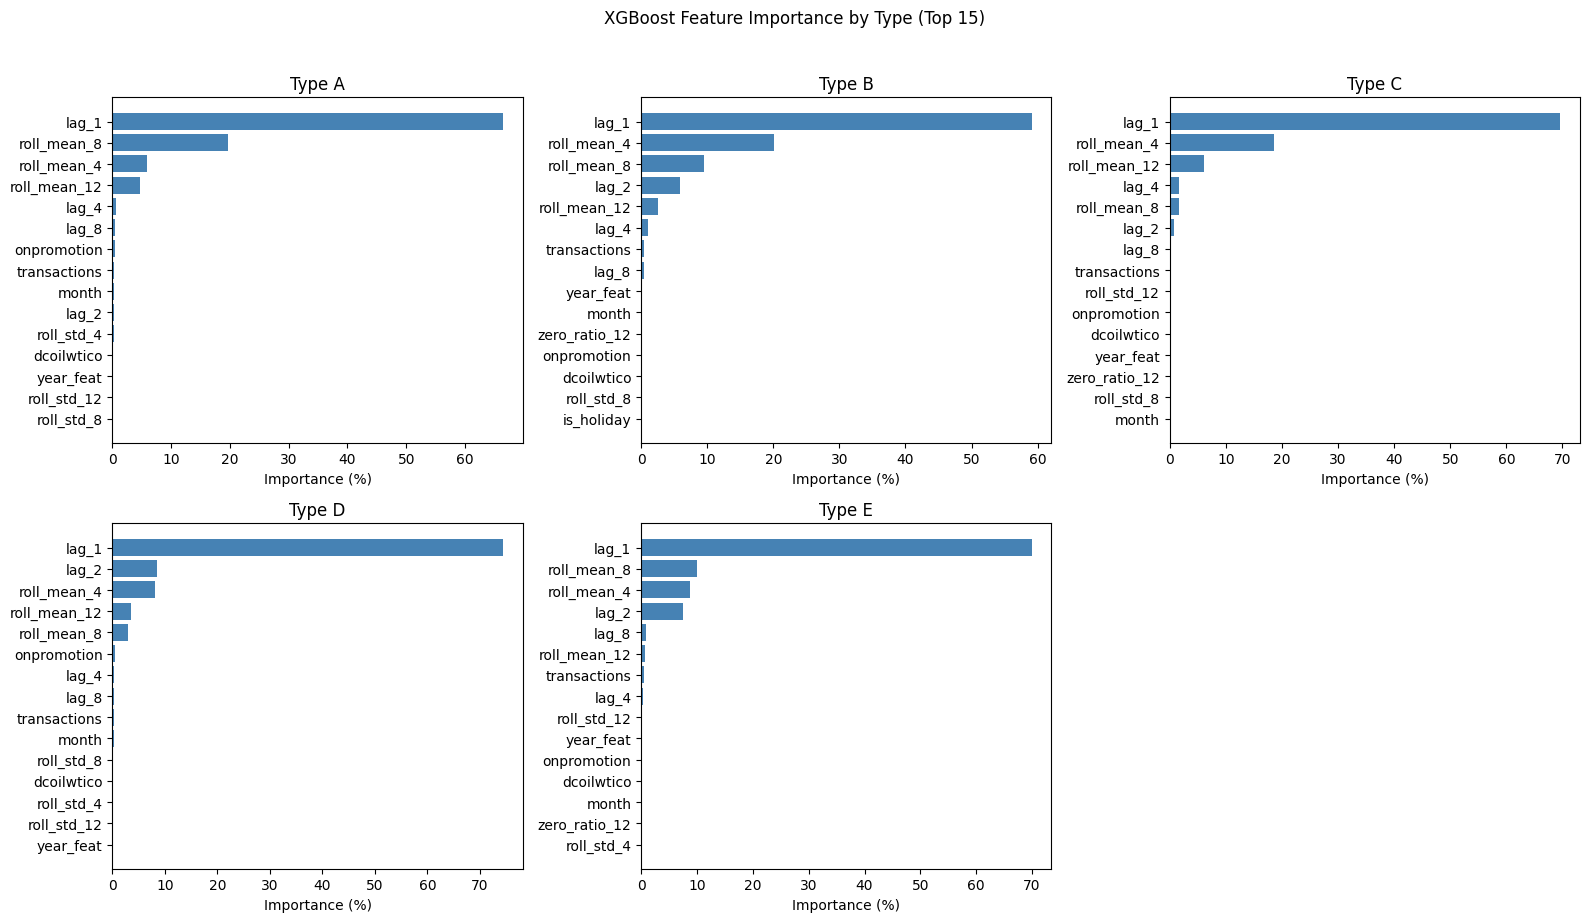

In [3]:
TOP_K = 15
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, t in enumerate(types):
    ax = axes[i]
    sub = imp_long[imp_long['type'] == t].nlargest(TOP_K, 'importance_pct')
    ax.barh(sub['feature'][::-1], sub['importance_pct'][::-1], color='steelblue')
    ax.set_title(f'Type {t}')
    ax.set_xlabel('Importance (%)')

axes[-1].set_visible(False)
fig.suptitle('XGBoost Feature Importance by Type (Top 15)', y=1.02)
plt.tight_layout()
plt.show()


### ③ type 간 공통·차별 피처

In [4]:
# type 평균 중요도
mean_imp = imp_pivot.mean(axis=1).sort_values(ascending=False)
print('=== 5 type 평균 Top 15 ===')
print(mean_imp.head(15).round(2))

# type 간 중요도 표준편차 — type마다 기여도가 다른 피처
std_imp = imp_pivot.std(axis=1).sort_values(ascending=False)
hetero = pd.DataFrame({
    'mean_pct': mean_imp,
    'std_across_types': std_imp,
}).sort_values('std_across_types', ascending=False)
print('\n=== type 간 중요도 편차 큰 피처 (차별적) ===')
print(hetero.head(10).round(2))


=== 5 type 평균 Top 15 ===
feature
lag_1           67.93
roll_mean_4     12.28
roll_mean_8      8.75
lag_2            4.56
roll_mean_12     3.52
lag_4            0.82
lag_8            0.47
transactions     0.36
onpromotion      0.25
month            0.17
year_feat        0.15
dcoilwtico       0.15
roll_std_12      0.14
roll_std_8       0.12
roll_std_4       0.12
dtype: float64

=== type 간 중요도 편차 큰 피처 (차별적) ===
              mean_pct  std_across_types
feature                                 
roll_mean_8       8.75              7.18
roll_mean_4      12.28              6.57
lag_1            67.93              5.68
lag_2             4.56              3.81
roll_mean_12      3.52              2.08
lag_4             0.82              0.56
lag_8             0.47              0.25
onpromotion       0.25              0.15
transactions      0.36              0.13
month             0.17              0.07


### ④ 해석 가이드

- **lag·roll_mean** 계열이 상위면 → 해당 type은 **과거 판매 수준·추세**가 예측의 핵심
- **zero_ratio·ADI·CV²** 상위면 → **간헐 수요** 특성이 모델에 반영
- **oil·holiday·transactions** 상위면 → **외생·매장 활동** 변수가 type별로 설명력 보유
- type 간 `std_across_types`가 크면 → **매장 유형마다 다른 드라이버** (SBC/ML scheme 차이 해석에 참고)

> 본 분석은 **튜닝 전 고정 하이퍼파라미터** 기준입니다. 14장 Optuna 후 중요도가 달라질 수 있습니다.

In [5]:
out = DATA_PROCESSED
imp_long.to_csv(out / 'xgboost_feature_importance_by_type.csv', index=False)
imp_pivot.round(4).to_csv(out / 'xgboost_feature_importance_pivot.csv')
print('저장:', out / 'xgboost_feature_importance_by_type.csv')


저장: C:\Users\kjh\ai-retail-demandforecasting\data\processed\xgboost_feature_importance_by_type.csv
